# Student Performance Analysis - Missing Values

This notebook analyzes the student performance dataset, focusing on identifying and visualizing missing values in the data.

## Import Required Libraries

First, we'll import the necessary Python libraries for data analysis and visualization.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Load Dataset

Now we'll load the student performance dataset from the CSV file and display the first few rows to examine its structure.

In [5]:
# Read the CSV file
df = pd.read_csv('data/StudentPerformanceFactors.csv')

# Display the first few rows
print("First few rows of the dataset:")
display(df.head())

# Display basic information about the dataset
print("\nDataset information:")
display(df.info())

First few rows of the dataset:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence            

None

## Check Missing Values

Let's analyze the missing values in our dataset using various pandas methods.

In [6]:
# Check for missing values in each column
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame with missing value information
missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

# Display missing value information
print("Missing values analysis:")
display(missing_info[missing_info['Missing Values'] > 0])

Missing values analysis:


,Missing Values,Missing Percentage
Teacher_Quality,78,1.180566
Parental_Education_Level,90,1.362192
Distance_from_Home,67,1.014076


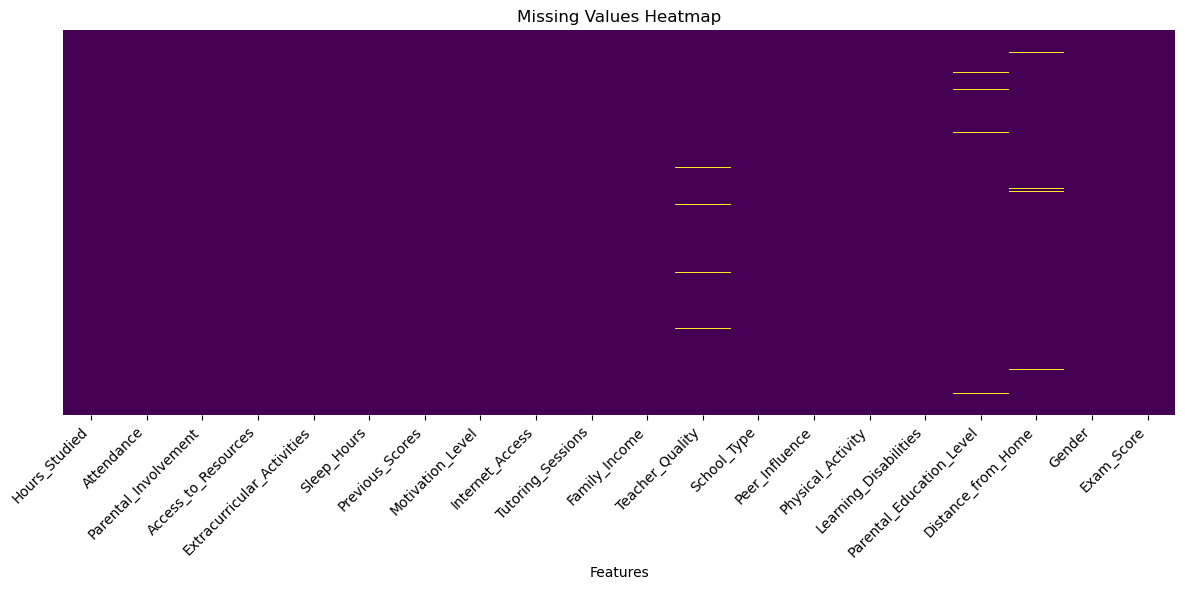

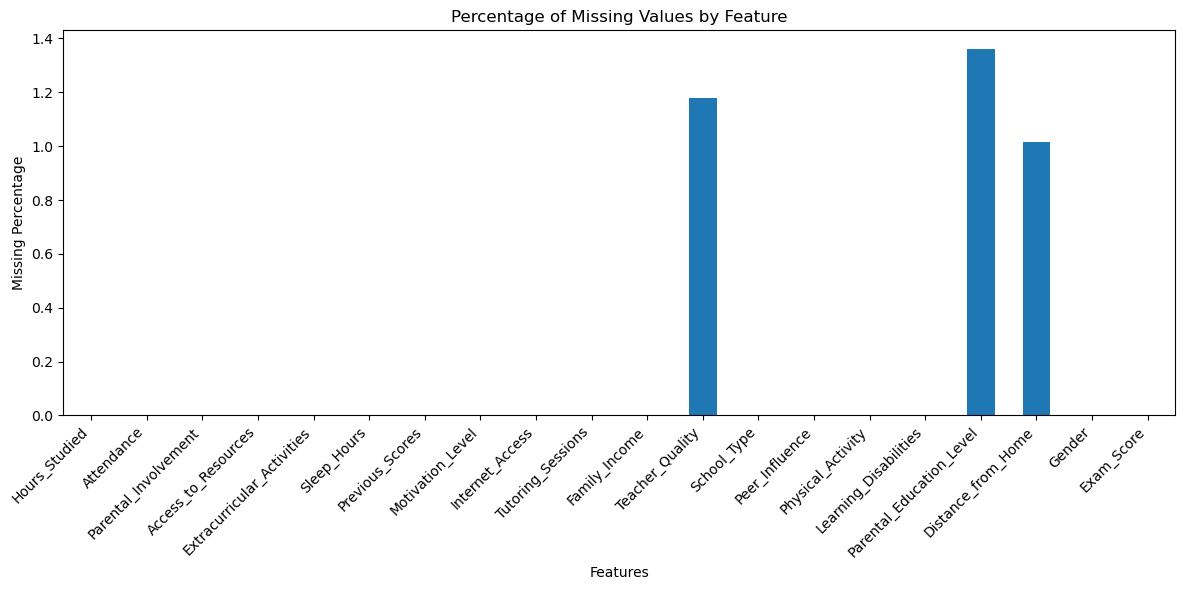

In [7]:
# Create a heatmap of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Create a bar plot of missing value percentages
plt.figure(figsize=(12, 6))
missing_percentage.plot(kind='bar')
plt.title('Percentage of Missing Values by Feature')
plt.xlabel('Features')
plt.ylabel('Missing Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary Statistics

Let's look at some basic statistical information about our dataset.

In [8]:
# Display summary statistics
print("Summary statistics for numeric columns:")
display(df.describe())

# Display column types
print("\nColumn data types:")
display(df.dtypes)

Summary statistics for numeric columns:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000



Column data types:


Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

## KNN Imputation for Specific Columns

We'll perform KNN imputation for the following columns:
- Teacher_Quality
- Parental_Education_Level
- Distance_from_Home

In [18]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

# Read the original dataset
df = pd.read_csv('data/StudentPerformanceFactors.csv')

# Display info about the columns we'll impute
columns_to_impute = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
print("Information about columns to impute:")
print("\nMissing values in target columns:")
print(df[columns_to_impute].isnull().sum())
print("\nData types of target columns:")
print(df[columns_to_impute].dtypes)

Information about columns to impute:

Missing values in target columns:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Data types of target columns:
Teacher_Quality             object
Parental_Education_Level    object
Distance_from_Home          object
dtype: object


In [19]:
# Create a copy of the dataframe
df_imputed = df.copy()

# Initialize dictionary to store label encoders
label_encoders = {}

# Prepare data for imputation
for column in columns_to_impute:
    if df[column].dtype == 'object':  # If column is categorical
        # Create and fit label encoder
        label_encoders[column] = LabelEncoder()
        # Fill NaN with a temporary value
        df_imputed[column].fillna('missing', inplace=True)
        # Encode the column
        df_imputed[column] = label_encoders[column].fit_transform(df_imputed[column])
    else:  # If column is numerical
        # Convert to float type to ensure compatibility with KNN imputer
        df_imputed[column] = df_imputed[column].astype(float)

print("\nColumns prepared for imputation:")
for column in columns_to_impute:
    print(f"{column}: {'categorical' if column in label_encoders else 'numerical'}")


Columns prepared for imputation:
Teacher_Quality: categorical
Parental_Education_Level: categorical
Distance_from_Home: categorical


C:\Users\46791130\AppData\Local\Temp\ipykernel_4284\2156696270.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[column].fillna('missing', inplace=True)
C:\Users\46791130\AppData\Local\Temp\ipykernel_4284\2156696270.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [20]:
# Initialize the KNN imputer
imputer = KNNImputer(n_neighbors=5)

# Create a subset of the data with only the columns we want to impute
subset_for_imputation = df_imputed[columns_to_impute]

# Perform imputation
imputed_values = imputer.fit_transform(subset_for_imputation)

# Replace the values in the original dataframe
df_imputed[columns_to_impute] = imputed_values

print("Imputation completed. Checking for any remaining missing values:")
print(df_imputed[columns_to_impute].isnull().sum())

Imputation completed. Checking for any remaining missing values:
Teacher_Quality             0
Parental_Education_Level    0
Distance_from_Home          0
dtype: int64


In [21]:
# Convert categorical variables back to their original categories
for column in columns_to_impute:
    if column in label_encoders:
        # Round the imputed values to nearest integer since LabelEncoder uses integers
        df_imputed[column] = np.round(df_imputed[column])
        # Convert back to original categories
        df_imputed[column] = label_encoders[column].inverse_transform(df_imputed[column].astype(int))

# Save the imputed dataset
output_file = 'Student_imputed_data.csv'
df_imputed.to_csv(output_file, index=False)
print(f"\nImputed data saved to {output_file}")

# Display sample of imputed data
print("\nSample of imputed data:")
display(df_imputed[columns_to_impute].head())


Imputed data saved to Student_imputed_data.csv

Sample of imputed data:


,Teacher_Quality,Parental_Education_Level,Distance_from_Home
0,Medium,High School,Near
1,Medium,College,Moderate
2,Medium,Postgraduate,Near
3,Medium,High School,Moderate
4,High,College,Near


In [22]:
# Check for missing values in each column
missing_values = df_imputed.isnull().sum()
missing_percentage = (df_imputed.isnull().sum() / len(df)) * 100

# Create a DataFrame with missing value information
missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

# Display missing value information
print("Missing values analysis:")
display(missing_info[missing_info['Missing Values'] > 0])

Missing values analysis:


,Missing Values,Missing Percentage


## Continuous Variables Analysis

We'll analyze the relationships between continuous variables in the imputed dataset using:
1. Correlation analysis with heatmap
2. Scatter plot matrix
3. VIF (Variance Inflation Factor) scores

In [23]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Read the imputed dataset
df = pd.read_csv('Student_imputed_data.csv')

# Select numerical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
continuous_df = df[numeric_columns]

print("Continuous variables in the dataset:")
print(continuous_df.columns.tolist())

# Display basic statistics of continuous variables
print("\nSummary statistics:")
display(continuous_df.describe())

Continuous variables in the dataset:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

Summary statistics:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


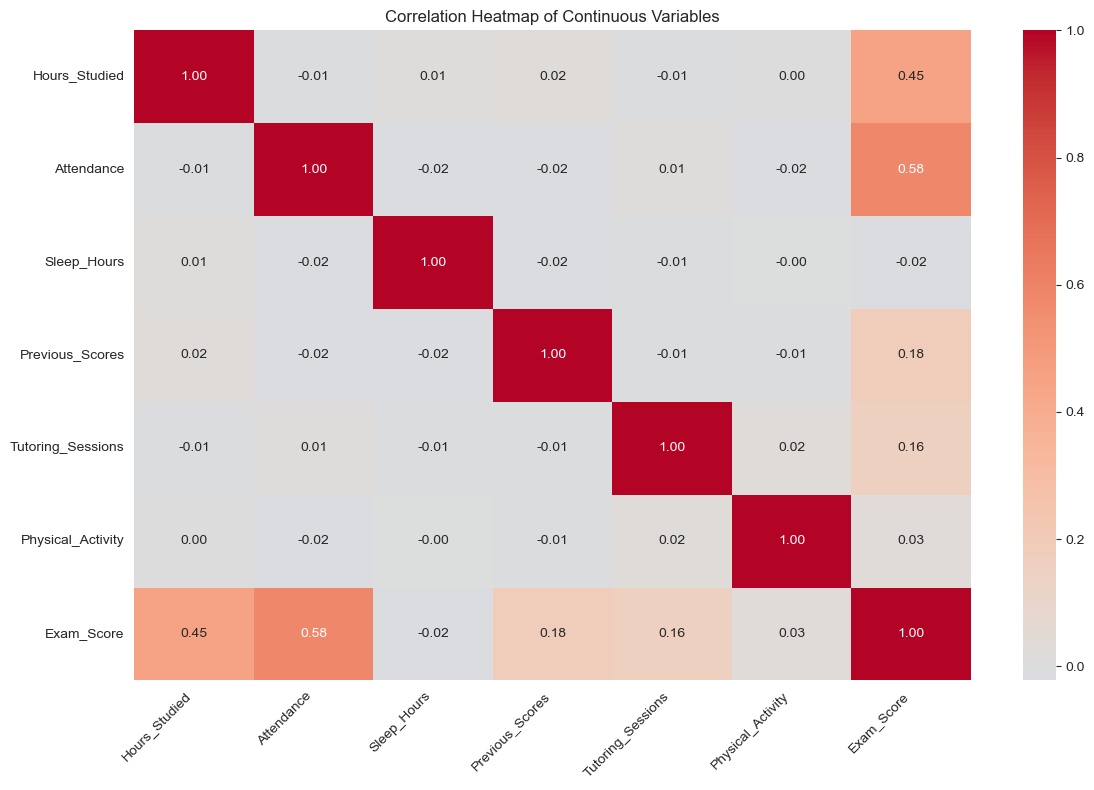


Correlation Matrix:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.00,-0.01,0.01,0.02,-0.01,0.00,0.45
Attendance,-0.01,1.00,-0.02,-0.02,0.01,-0.02,0.58
Sleep_Hours,0.01,-0.02,1.00,-0.02,-0.01,-0.00,-0.02
Previous_Scores,0.02,-0.02,-0.02,1.00,-0.01,-0.01,0.18
Tutoring_Sessions,-0.01,0.01,-0.01,-0.01,1.00,0.02,0.16
Physical_Activity,0.00,-0.02,-0.00,-0.01,0.02,1.00,0.03
Exam_Score,0.45,0.58,-0.02,0.18,0.16,0.03,1.00


In [24]:
# Calculate correlation matrix
correlation_matrix = continuous_df.corr()

# Create a heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            cmap='coolwarm',  # Color scheme
            center=0,  # Center the colormap at 0
            fmt='.2f')  # Format correlation values to 2 decimal places
plt.title('Correlation Heatmap of Continuous Variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Display the correlation matrix
print("\nCorrelation Matrix:")
display(correlation_matrix.round(2))

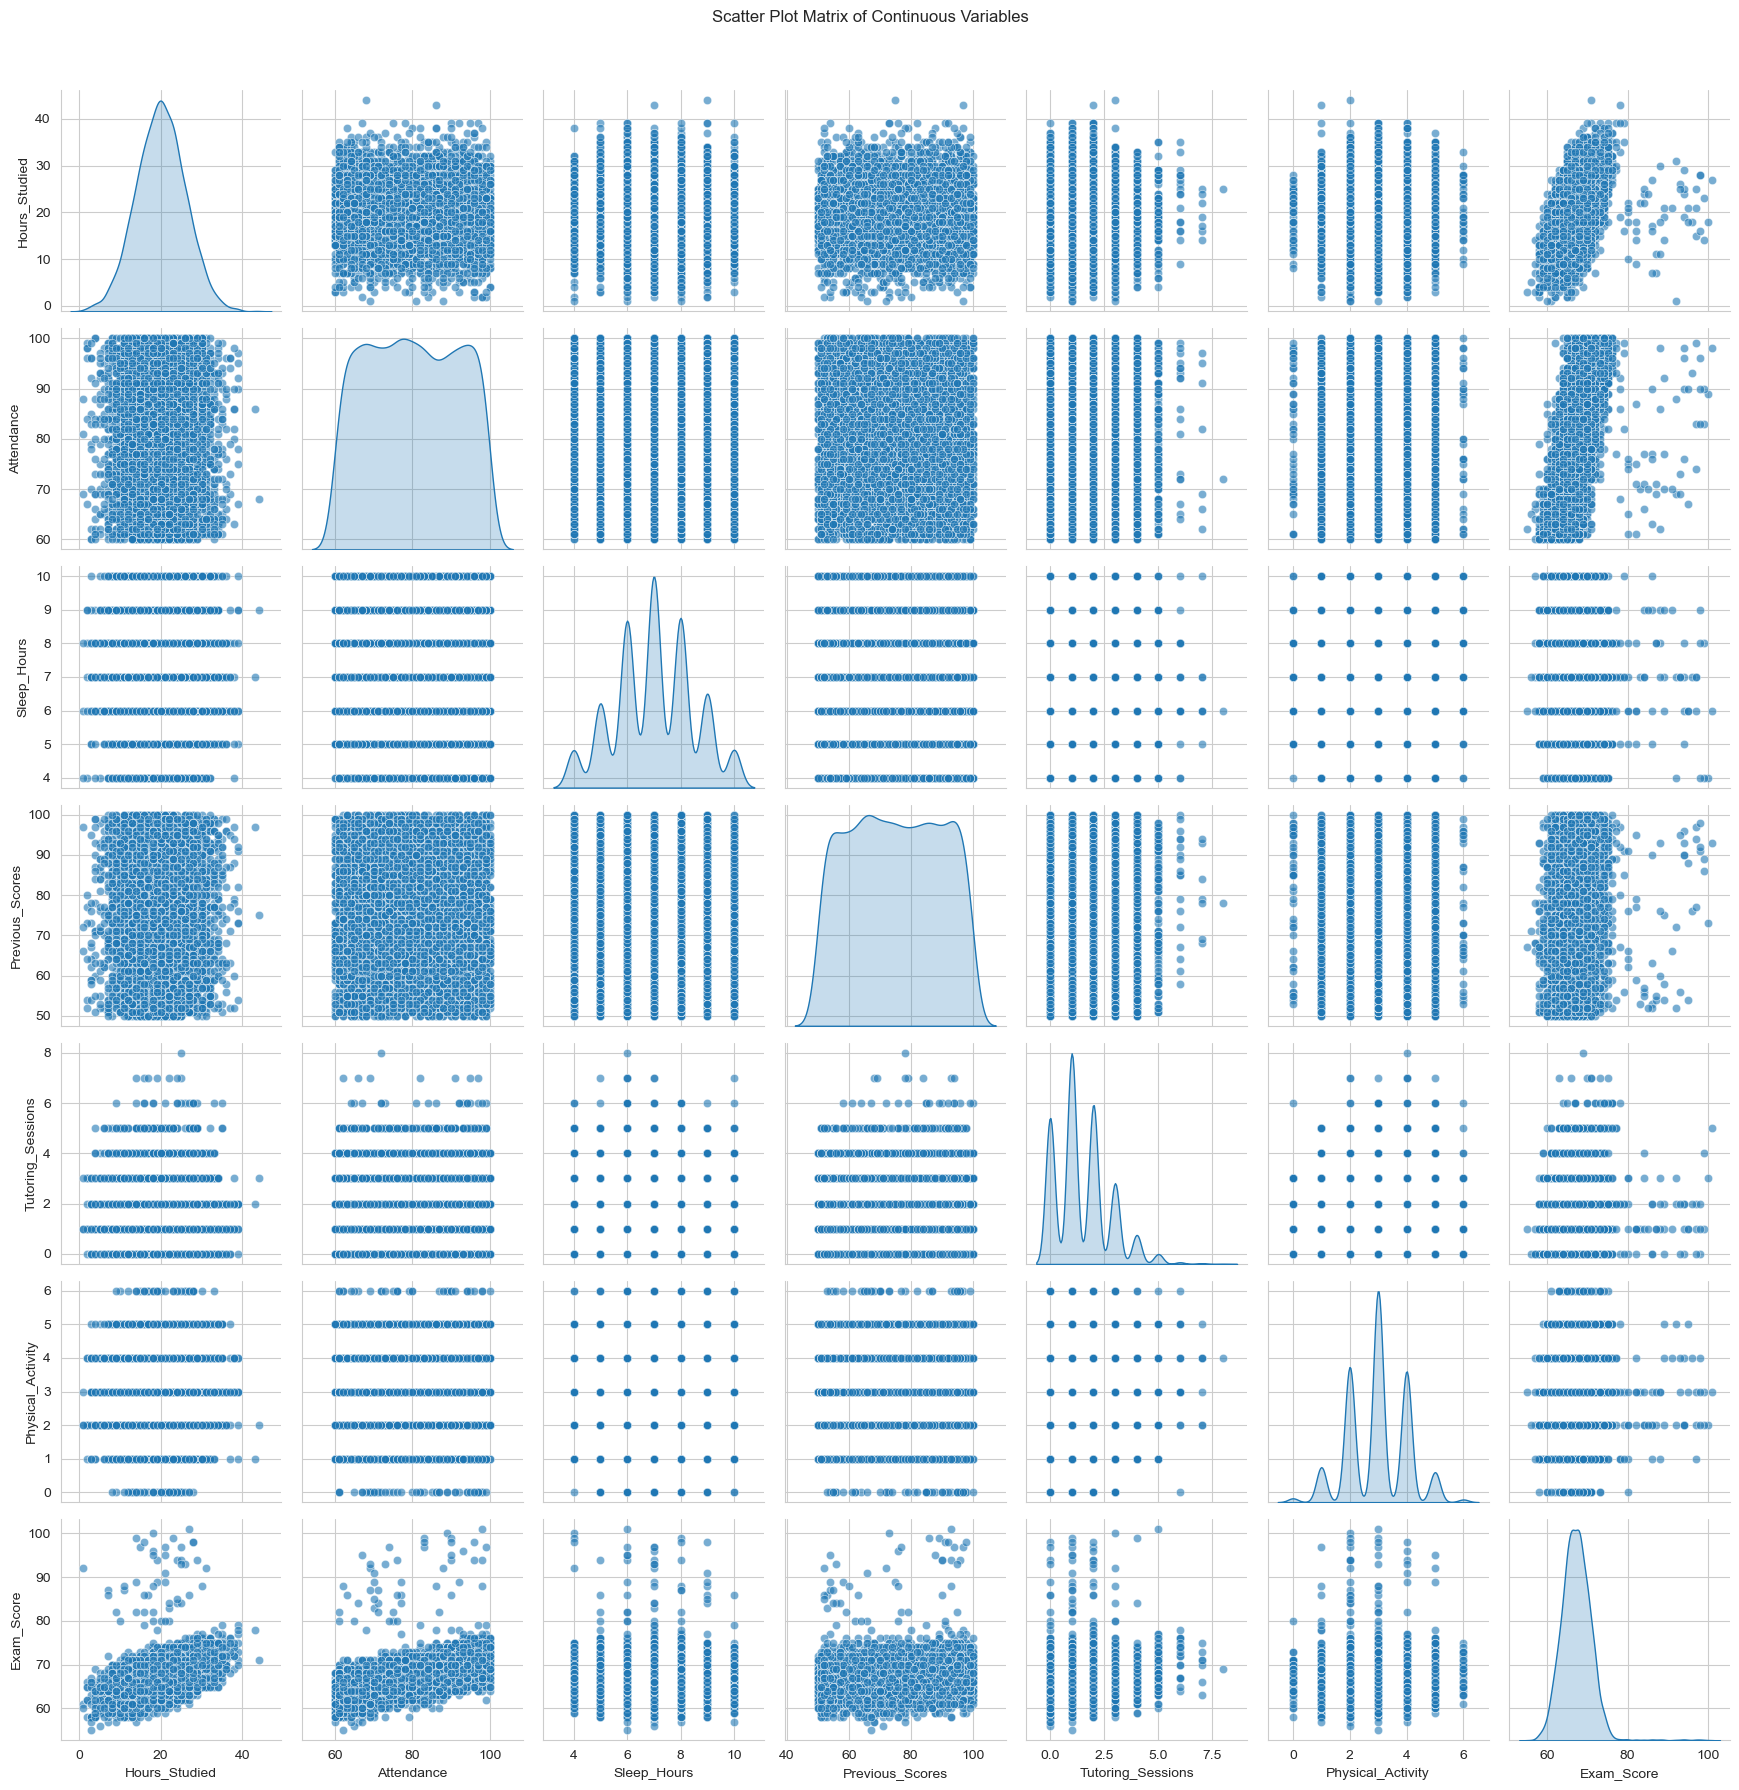

In [25]:
# Create scatter plot matrix
sns.set_style("whitegrid")
scatter_plot = sns.pairplot(continuous_df, 
                           diag_kind='kde',  # Show kernel density estimation on diagonal
                           plot_kws={'alpha': 0.6})  # Set transparency for better visibility
plt.suptitle('Scatter Plot Matrix of Continuous Variables', y=1.02)
plt.tight_layout()
plt.show()

# Reset the style
plt.style.use('default')


Variance Inflation Factors (VIF):


,Variable,VIF
1,Attendance,28.616943
3,Previous_Scores,21.523588
2,Sleep_Hours,19.132006
0,Hours_Studied,11.121679
5,Physical_Activity,8.589415
4,Tutoring_Sessions,2.445823


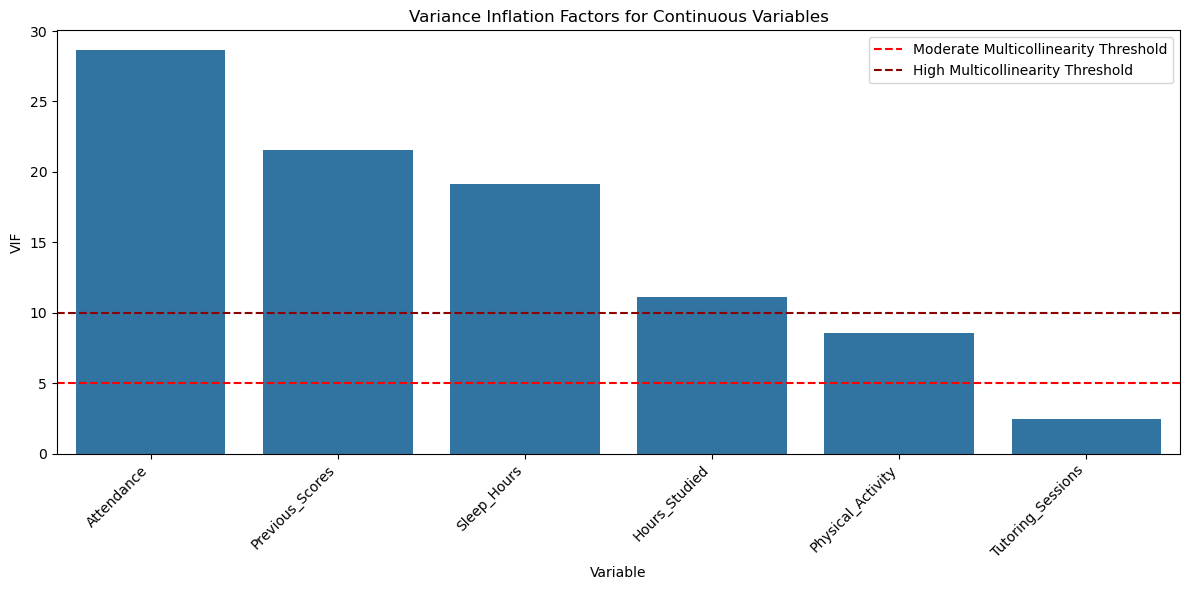


Interpretation Guide:
- VIF > 10: High multicollinearity
- VIF > 5: Moderate multicollinearity
- VIF < 5: Low multicollinearity


In [44]:
# Calculate VIF for each continuous variable
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

# Calculate and display VIF scores
vif_scores = calculate_vif(continuous_df.iloc[:,:-1])
print("\nVariance Inflation Factors (VIF):")
display(vif_scores)

# Create a bar plot of VIF scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Variable', y='VIF', data=vif_scores)
plt.title('Variance Inflation Factors for Continuous Variables')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=5, color='r', linestyle='--', label='Moderate Multicollinearity Threshold')
plt.axhline(y=10, color='darkred', linestyle='--', label='High Multicollinearity Threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation Guide:")
print("- VIF > 10: High multicollinearity")
print("- VIF > 5: Moderate multicollinearity")
print("- VIF < 5: Low multicollinearity")

## Categorical Data Analysis

We'll analyze the categorical variables using:
1. Bar charts to show frequency distributions
2. Box plots to show relationships with numerical variables
3. Pie charts to show proportions

## Categorical Data Visualization

We'll create three types of plots for categorical variables:
1. Bar charts (showing frequency distribution)
2. Box plots (showing relationship with numerical variables)
3. Pie charts (showing proportions)

Each visualization will:
- Use a 4-column subplot layout
- Apply consistent colors from the Dark2 palette
- Maintain consistent category ordering

In [66]:
# Setup for categorical visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Read the imputed data
df = pd.read_csv('Student_imputed_data.csv')

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Calculate layout dimensions
n_cols = 4  # as specified
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

# Set up Dark2 color palette
colors = plt.cm.Dark2.colors

# Define category ordering
category_order = {
    'high': 0, 'medium': 1, 'low': 2,  # high-medium-low
    'yes': 0, 'no': 1,  # yes-no
    'positive': 0, 'neutral': 1, 'negative': 2,  # positive-neutral-negative
    'far': 0, 'moderate': 1, 'near': 2  # far-moderate-near
}

# Create color mappings for each categorical column
column_color_maps = {}
for column in categorical_columns:
    unique_values = df[column].unique()
    # Sort values according to specified order if applicable
    if any(val.lower() in category_order for val in unique_values):
        sorted_values = sorted(unique_values, key=lambda x: category_order.get(x.lower(), 999))
    else:
        sorted_values = np.sort(unique_values)
    # Assign colors cyclically from Dark2 palette
    column_color_maps[column] = {val: colors[i % len(colors)] for i, val in enumerate(sorted_values)}

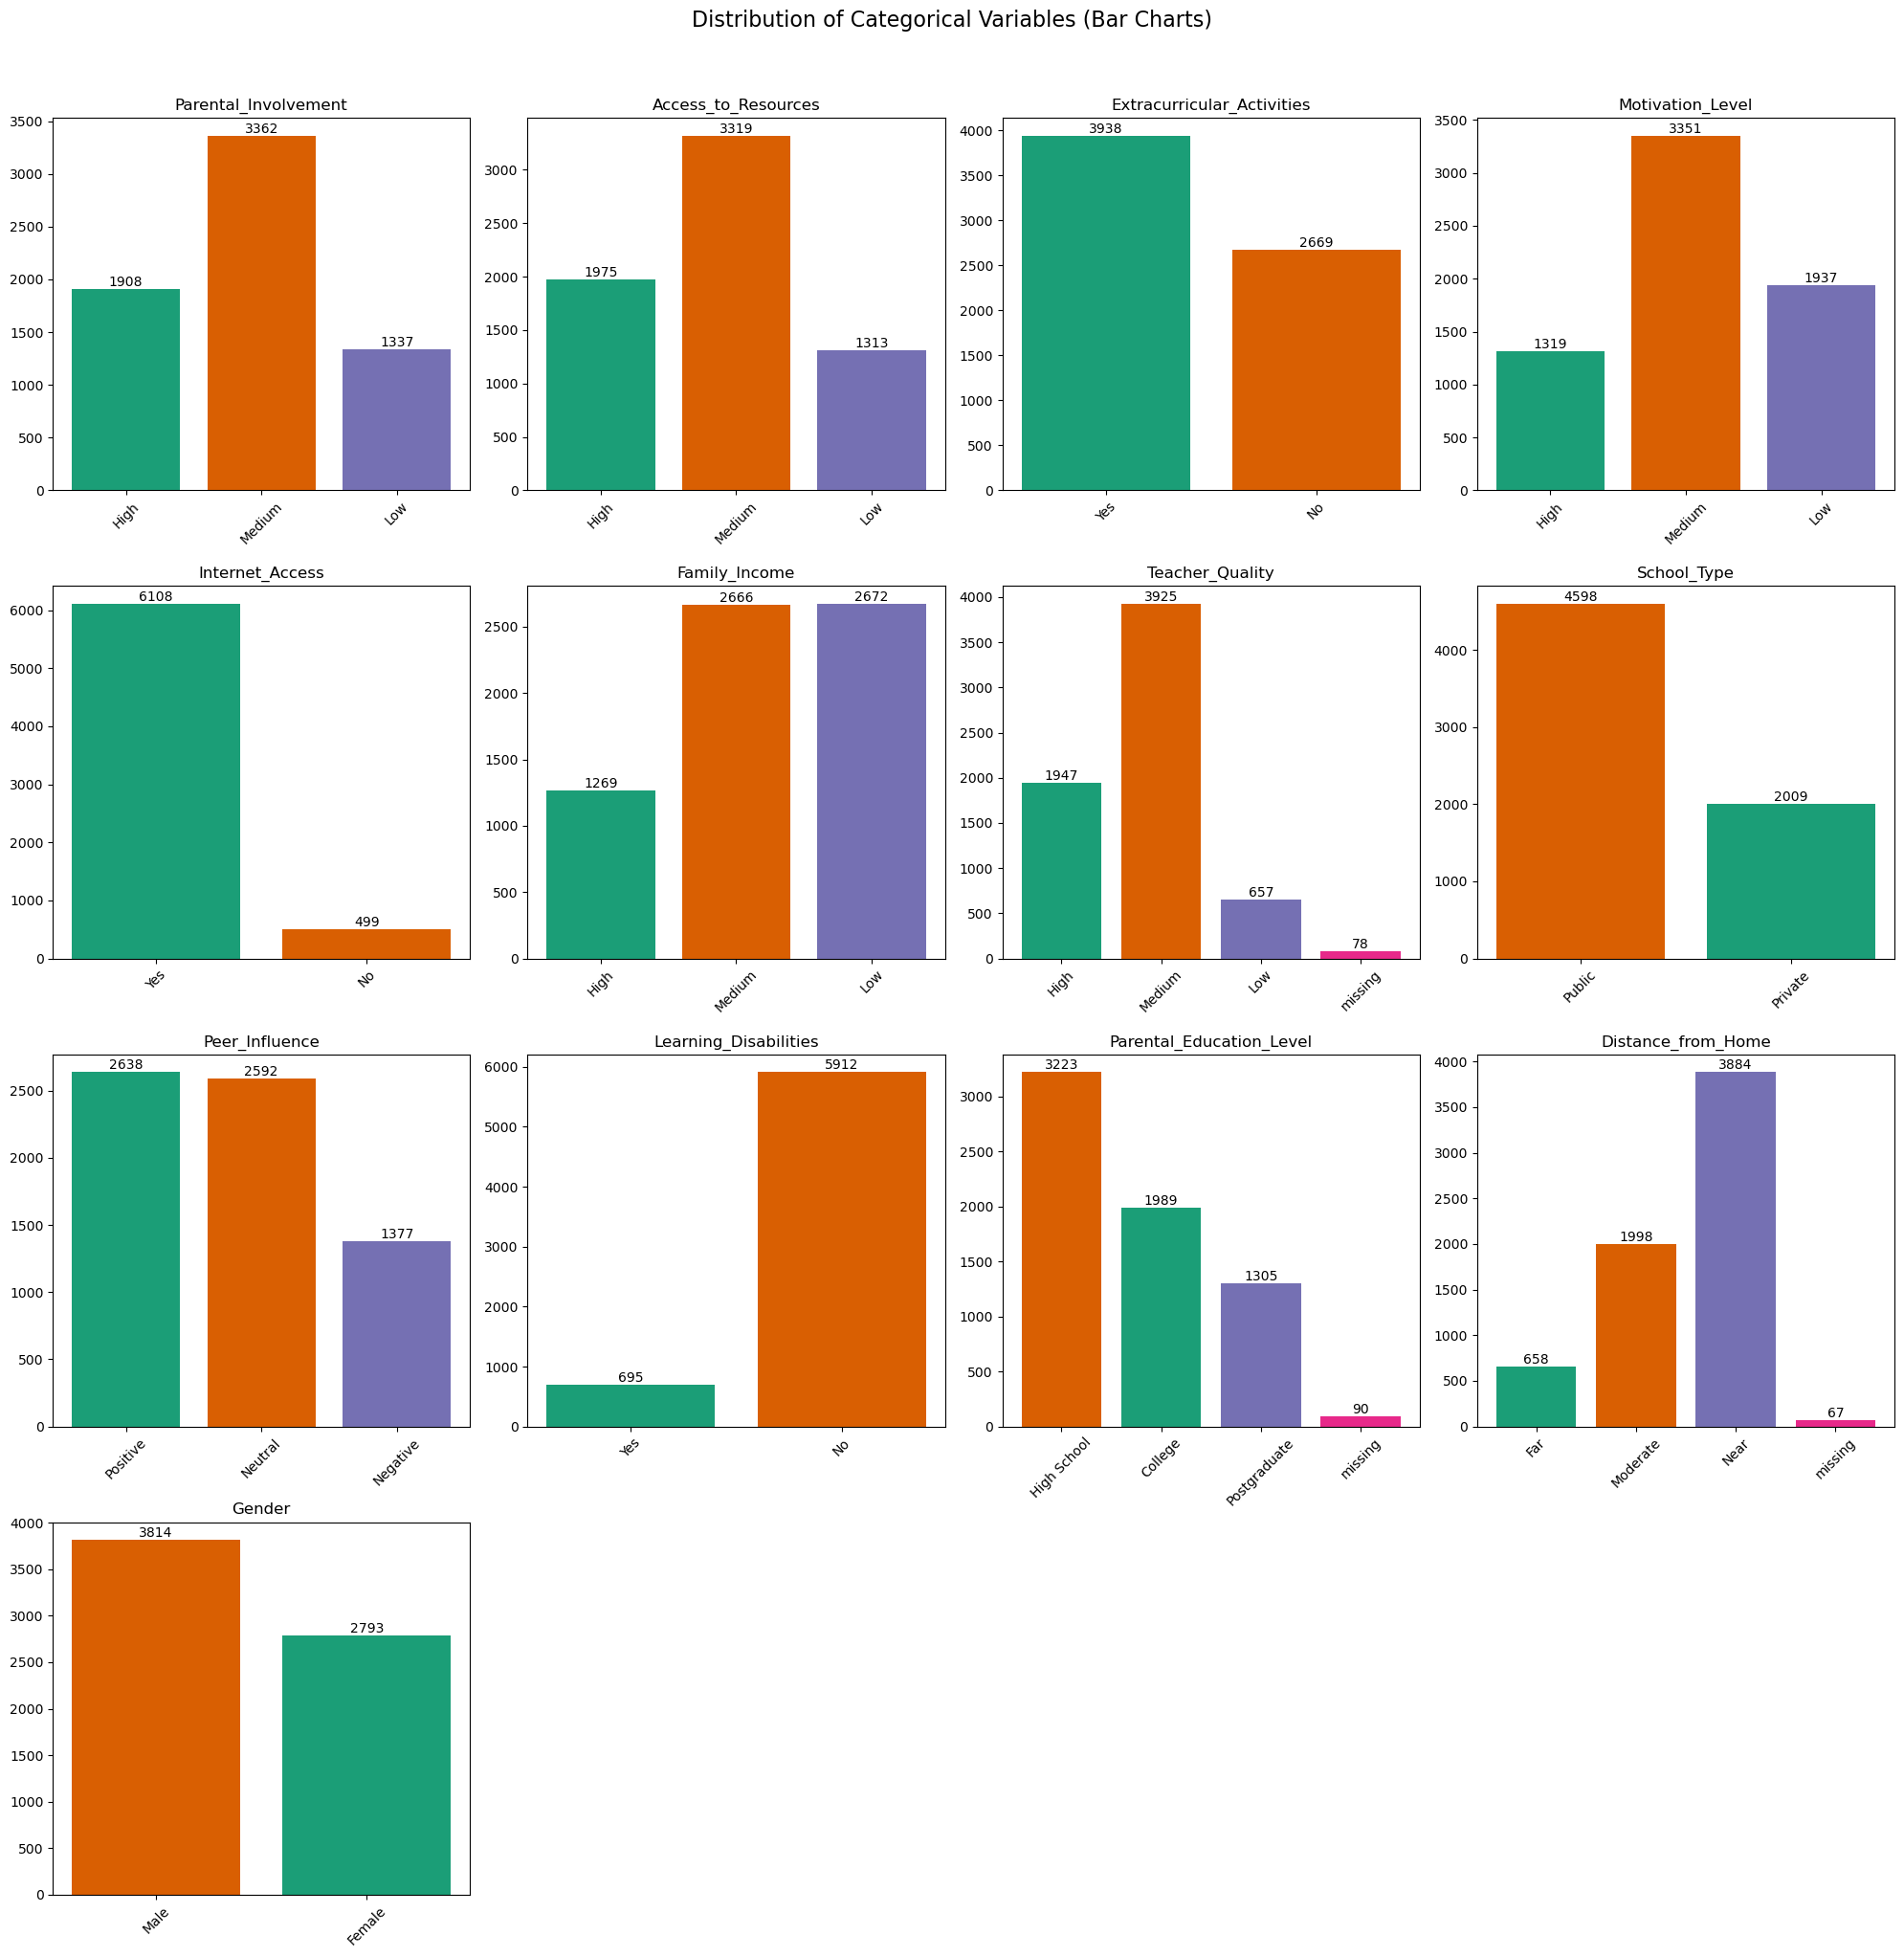

In [70]:
# Create bar chart subplots
fig = plt.figure(figsize=(20, 5*n_rows))
fig.suptitle('Distribution of Categorical Variables (Bar Charts)', fontsize=16, y=1.02)

for idx, column in enumerate(categorical_columns):
    ax = plt.subplot(n_rows, n_cols, idx+1)
    
    # Calculate percentages and sort according to specified order
    value_counts = df[column].value_counts()
    values_with_order = [(val, count) for val, count in value_counts.items()]
    
    # Sort based on category_order if applicable
    if any(cat.lower() in category_order for cat in value_counts.index):
        values_with_order.sort(key=lambda x: category_order.get(x[0].lower(), 999))
    
    # Split into separate lists after sorting
    categories = [x[0] for x in values_with_order]
    counts = [x[1] for x in values_with_order]
    
    # Get colors for this column's categories
    bar_colors = [column_color_maps[column][cat] for cat in categories]
    
    # Create bar plot with consistent colors
    bars = ax.bar(categories, counts, color=bar_colors)
    
    # Customize subplot
    ax.set_title(column)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
                f'{int(height)}',
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

C:\Users\46791130\AppData\Local\Temp\ipykernel_4284\720850371.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot([df[df[cat_col] == cat][exam_score_col] for cat in categories],
C:\Users\46791130\AppData\Local\Temp\ipykernel_4284\720850371.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot([df[df[cat_col] == cat][exam_score_col] for cat in categories],
C:\Users\46791130\AppData\Local\Temp\ipykernel_4284\720850371.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot([df[df[cat_col] == cat][exam_score_col] for cat in categories],
C:\Users\46791130\AppData

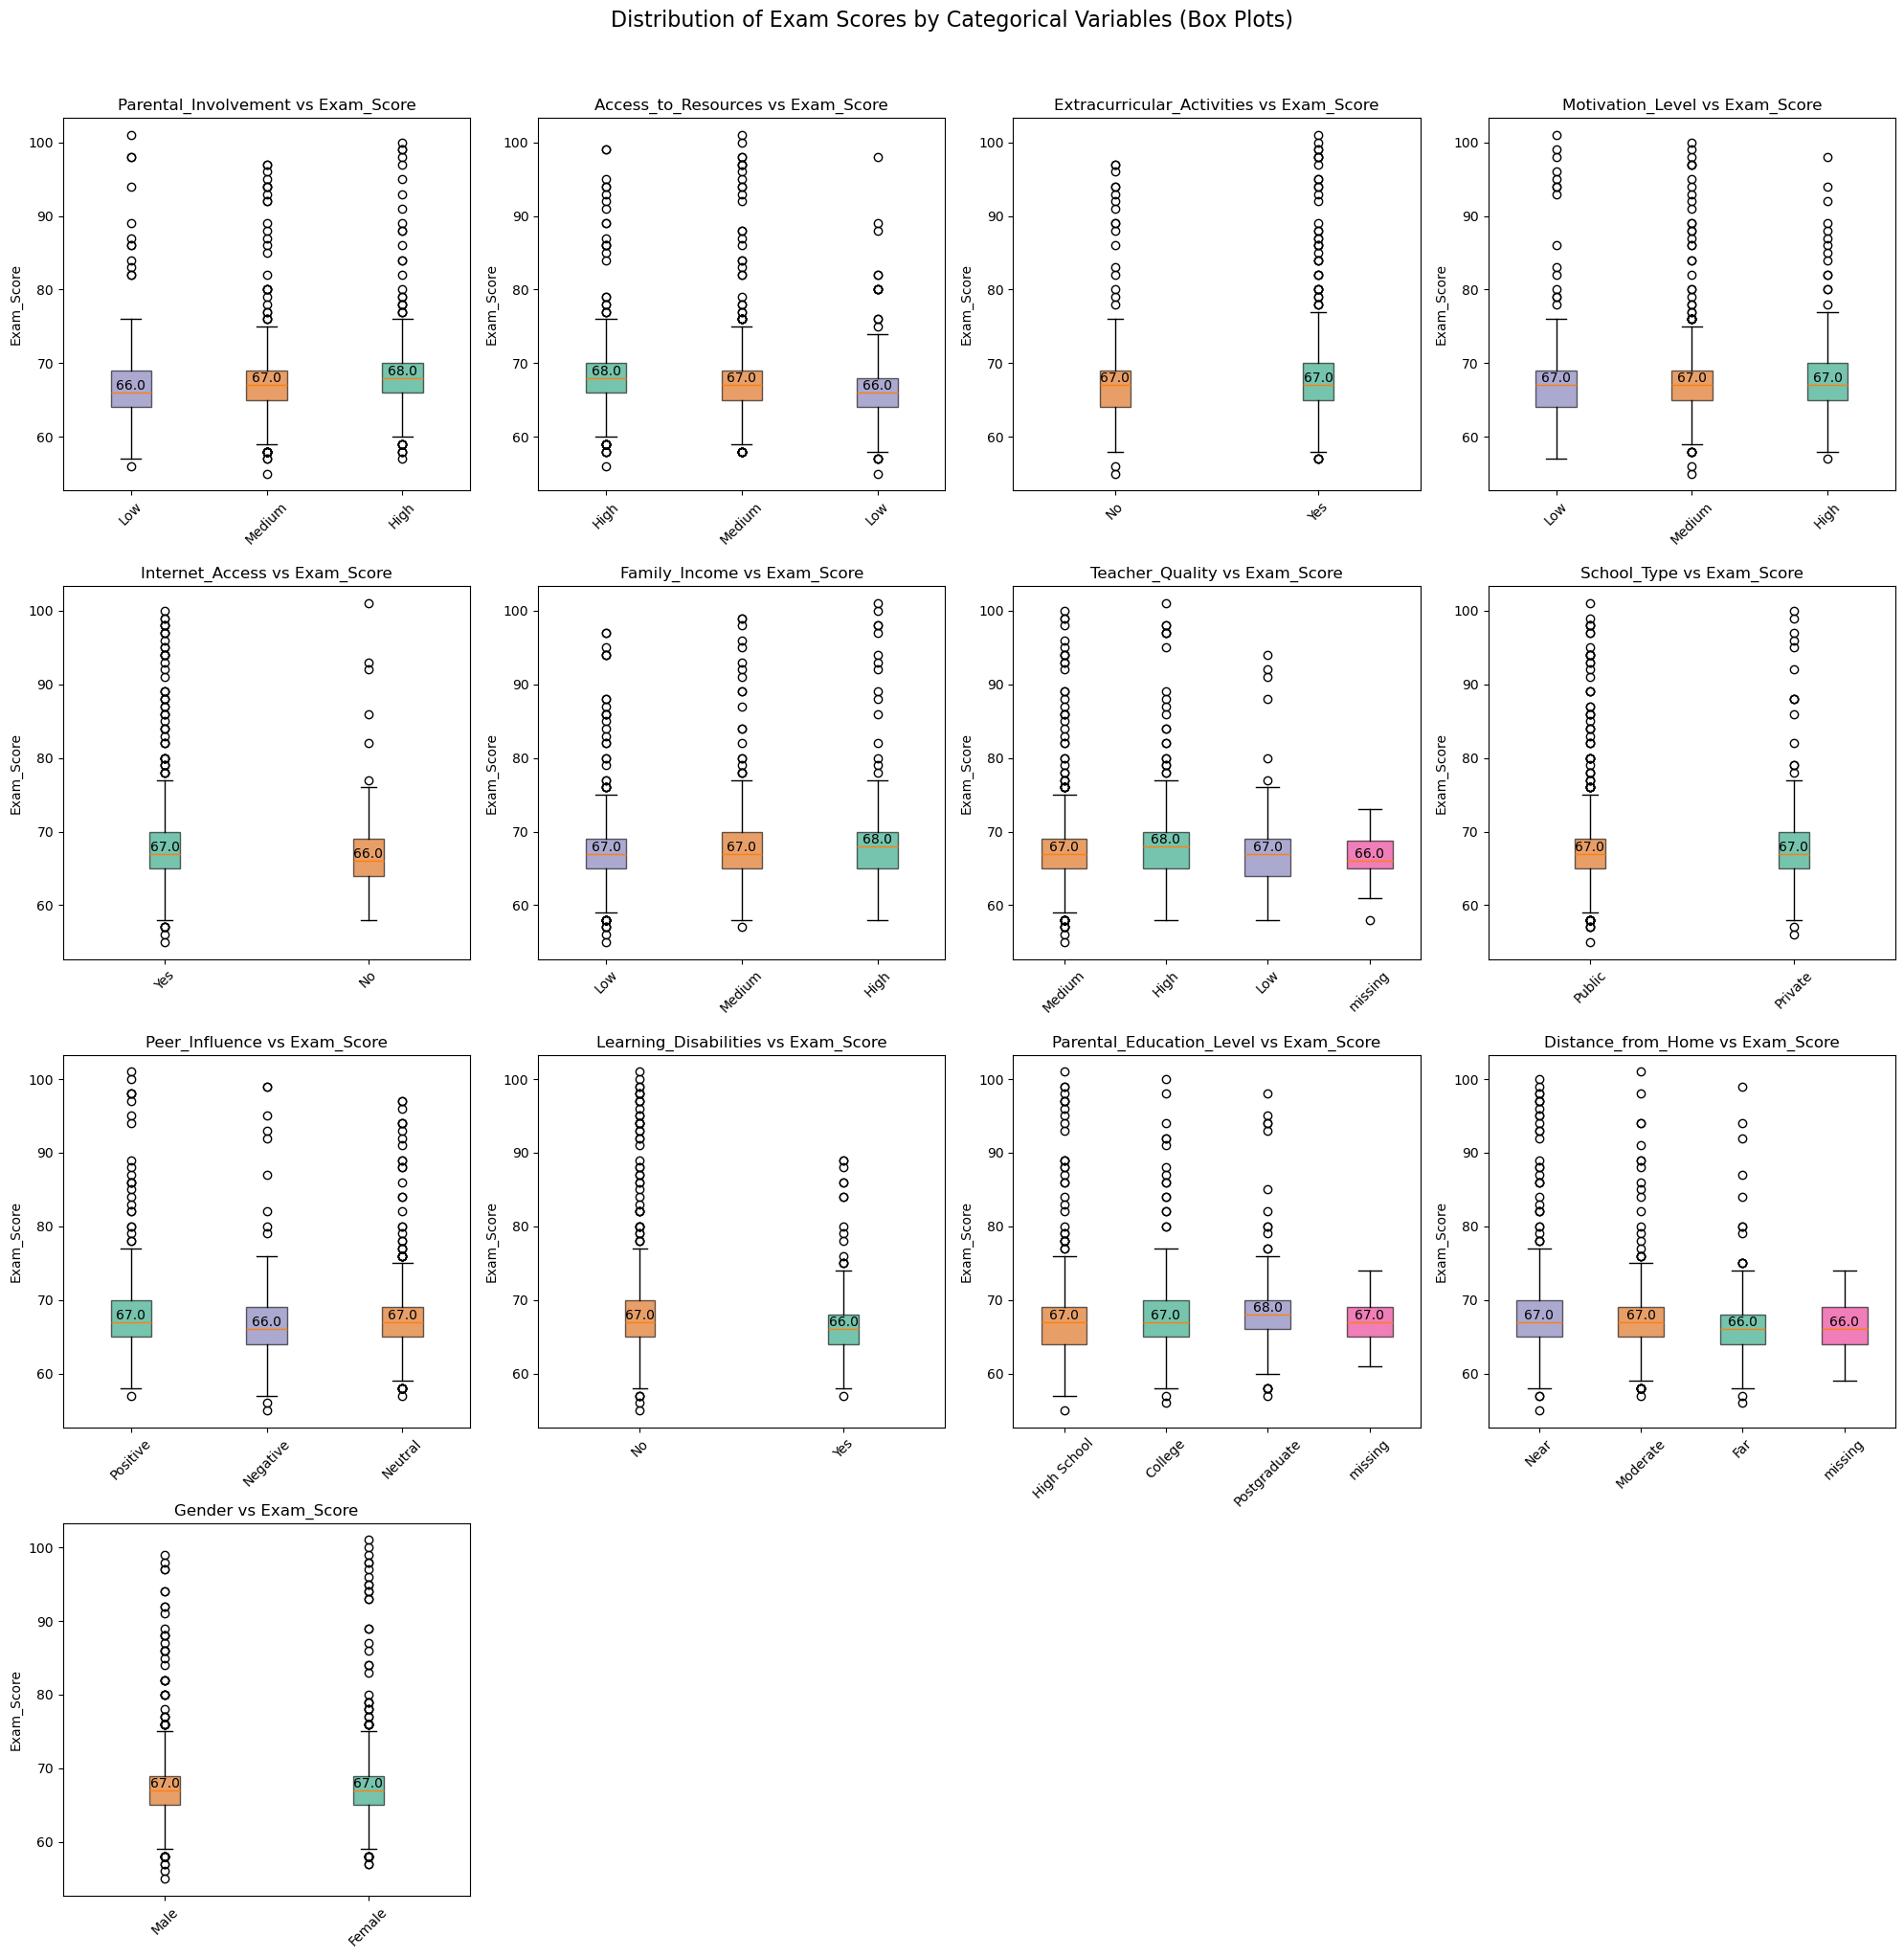


Summary statistics of Exam Score by categories:

Parental_Involvement:


,count,mean,std,median,min,max
Parental_Involvement,,,,,,
High,1908,68.09,3.95,68.0,57,100
Medium,3362,67.10,3.73,67.0,55,97
Low,1337,66.36,3.97,66.0,56,101



Access_to_Resources:


,count,mean,std,median,min,max
Access_to_Resources,,,,,,
High,1975,68.09,3.95,68.0,56,99
Medium,3319,67.13,3.87,67.0,58,101
Low,1313,66.20,3.56,66.0,55,98



Extracurricular_Activities:


...

,count,mean,std,median,min,max
Parental_Education_Level,,,,,,
College,1989,67.32,3.83,67.0,56,100
High School,3223,66.89,3.98,67.0,55,101
Postgraduate,1305,67.97,3.69,68.0,57,98
missing,90,67.06,3.28,67.0,61,74



Distance_from_Home:


,count,mean,std,median,min,max
Distance_from_Home,,,,,,
Far,658,66.46,4.14,66.0,56,99
Moderate,1998,66.98,3.79,67.0,57,101
Near,3884,67.51,3.88,67.0,55,100
missing,67,66.43,3.22,66.0,59,74



Gender:


,count,mean,std,median,min,max
Gender,,,,,,
Female,2793,67.24,4.05,67.0,57,101
Male,3814,67.23,3.77,67.0,55,99


In [87]:
# Create box plot subplots using Exam_score
fig = plt.figure(figsize=(20, 5*n_rows))
fig.suptitle('Distribution of Exam Scores by Categorical Variables (Box Plots)', fontsize=16, y=1.02)

# Use Exam_score as specified
exam_score_col = 'Exam_Score'

for idx, cat_col in enumerate(categorical_columns):
    ax = plt.subplot(n_rows, n_cols, idx+1)
    
    # Get categories in correct order
    categories = df[cat_col].unique()
    if any(cat.lower() in category_order for cat in categories):
        categories = sorted(categories, key=lambda x: category_order.get(x[0].lower(), 999))
    
    # Get color for each category
    box_colors = [column_color_maps[cat_col][cat] for cat in categories]
    
    # Create box plot using Exam_score
    boxplot = ax.boxplot([df[df[cat_col] == cat][exam_score_col] for cat in categories],
                        labels=categories,
                        patch_artist=True)
    
    # Set colors for boxes
    for box, color in zip(boxplot['boxes'], box_colors):
        box.set_facecolor(color)
        box.set_alpha(0.6)
    
    # Customize subplot
    ax.set_title(f'{cat_col} vs {exam_score_col}')
    ax.set_ylabel(exam_score_col)
    ax.tick_params(axis='x', rotation=45)
    
    # Add median values on top of each box
    medians = [np.median(df[df[cat_col] == cat][exam_score_col]) for cat in categories]
    for i, median in enumerate(medians):
        ax.text(i+1, median, f'{median:.1f}',
                horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

# Print summary statistics for exam scores
print("\nSummary statistics of Exam Score by categories:")
for column in categorical_columns:
    print(f"\n{column}:")
    stats_df = df.groupby(column)[exam_score_col].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
    stats_df = stats_df.round(2)
    
    # Sort according to specified order if applicable
    if any(cat.lower() in category_order for cat in stats_df.index):
        stats_df = stats_df.reindex(sorted(stats_df.index, key=lambda x: category_order.get(x.lower(), 999)))
    
    display(stats_df)

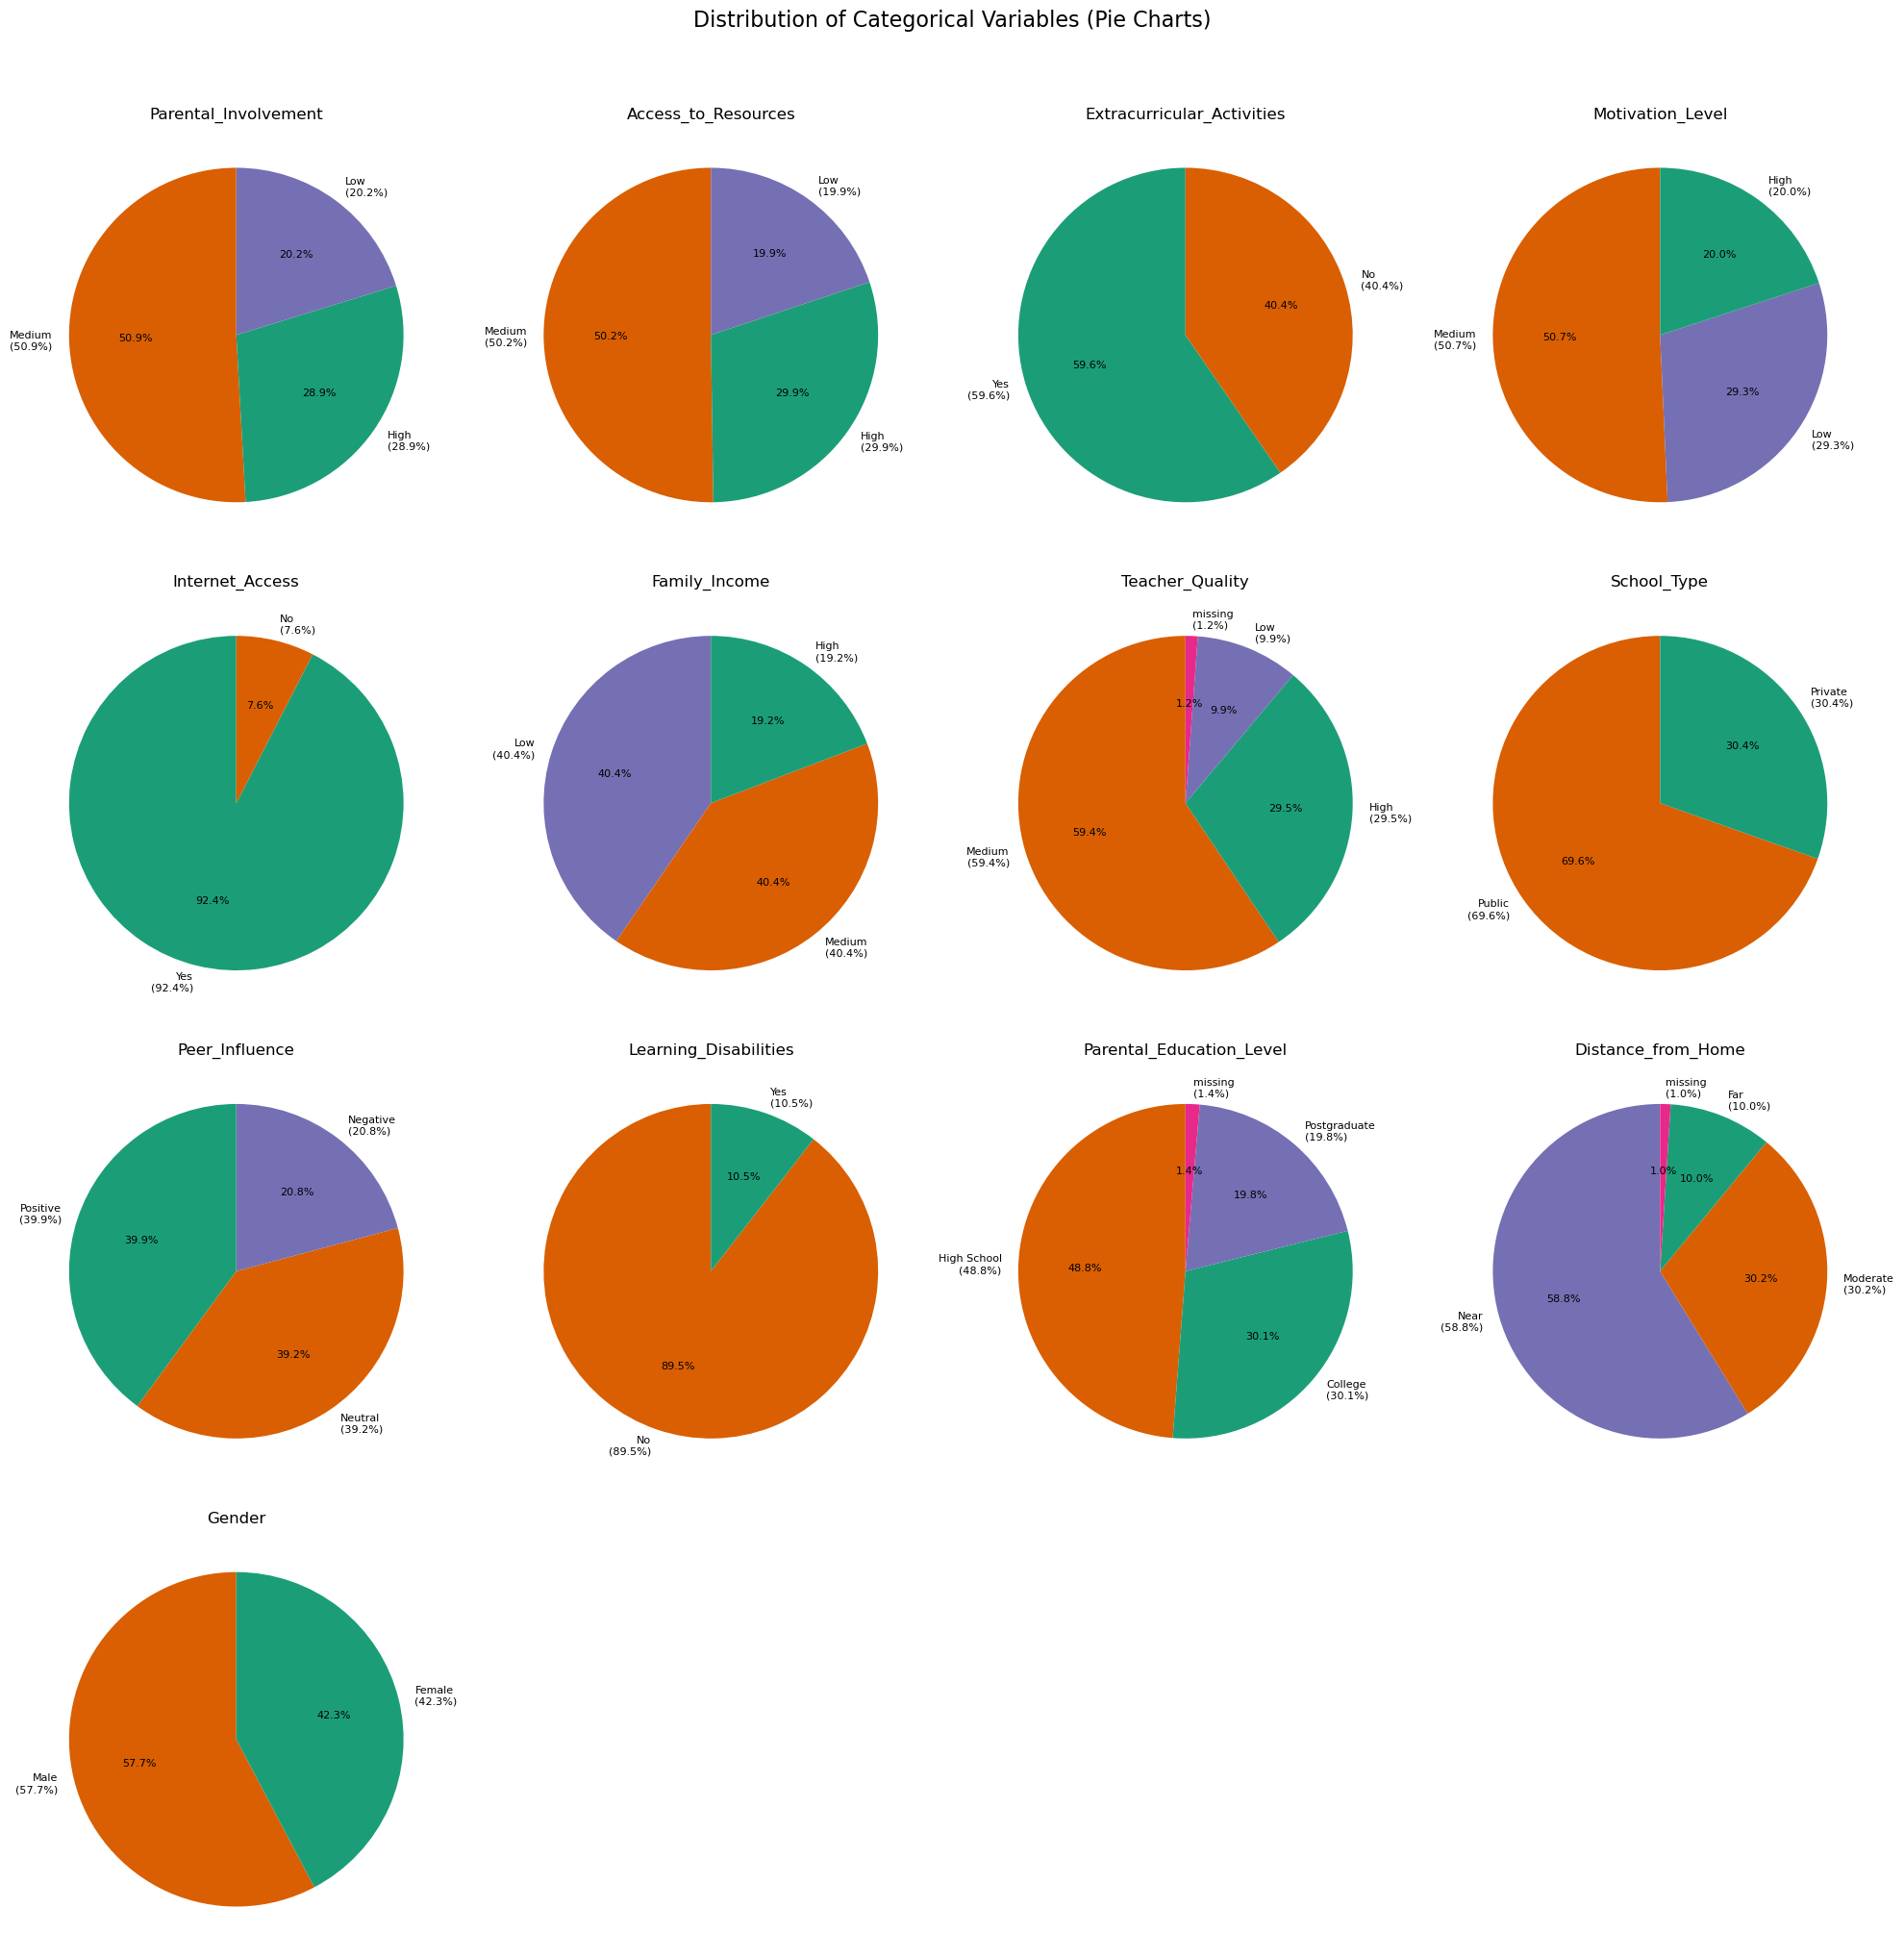


Final summary of categorical variables:

Parental_Involvement:


,Count,Percentage,Color (RGB)
Medium,3362,50.89%,"RGB(217, 95, 2)"
High,1908,28.88%,"RGB(27, 158, 119)"
Low,1337,20.24%,"RGB(117, 112, 179)"



Access_to_Resources:


,Count,Percentage,Color (RGB)
Medium,3319,50.23%,"RGB(217, 95, 2)"
High,1975,29.89%,"RGB(27, 158, 119)"
Low,1313,19.87%,"RGB(117, 112, 179)"



Extracurricular_Activities:


...

,Count,Percentage,Color (RGB)
High School,3223,48.78%,"RGB(217, 95, 2)"
College,1989,30.10%,"RGB(27, 158, 119)"
Postgraduate,1305,19.75%,"RGB(117, 112, 179)"
missing,90,1.36%,"RGB(231, 41, 138)"



Distance_from_Home:


,Count,Percentage,Color (RGB)
Near,3884,58.79%,"RGB(117, 112, 179)"
Moderate,1998,30.24%,"RGB(217, 95, 2)"
Far,658,9.96%,"RGB(27, 158, 119)"
missing,67,1.01%,"RGB(231, 41, 138)"



Gender:


,Count,Percentage,Color (RGB)
Male,3814,57.73%,"RGB(217, 95, 2)"
Female,2793,42.27%,"RGB(27, 158, 119)"


In [88]:
# Create pie chart subplots
fig = plt.figure(figsize=(20, 5*n_rows))
fig.suptitle('Distribution of Categorical Variables (Pie Charts)', fontsize=16, y=1.02)

for idx, column in enumerate(categorical_columns):
    ax = plt.subplot(n_rows, n_cols, idx+1)
    
    # Calculate percentages and sort according to specified order
    value_counts = df[column].value_counts()
    values_with_order = [(val, count) for val, count in value_counts.items()]
    
    # Split into separate lists after sorting
    categories = [x[0] for x in values_with_order]
    counts = [x[1] for x in values_with_order]
    percentages = [(count / len(df) * 100) for count in counts]
    
    # Get colors for this column's categories
    pie_colors = [column_color_maps[column][cat] for cat in categories]
    
    # Create pie chart with consistent colors
    wedges, texts, autotexts = ax.pie(percentages, 
                                     labels=[f'{label}\n({pct:.1f}%)' for label, pct in zip(categories, percentages)],
                                     autopct='%1.1f%%',
                                     colors=pie_colors,
                                     textprops={'fontsize': 8},
                                     startangle=90)  # Start at top
    
    # Customize subplot
    ax.set_title(column)
    
    # Adjust text properties
    plt.setp(autotexts, size=8)
    plt.setp(texts, size=8)

plt.tight_layout()
plt.show()

# Print final summary with color coding
print("\nFinal summary of categorical variables:")
for column in categorical_columns:
    print(f"\n{column}:")
    values_with_order = [(val, count) for val, count in df[column].value_counts().items()]
    categories = [x[0] for x in values_with_order]
    counts = [x[1] for x in values_with_order]
    colors = [column_color_maps[column][cat] for cat in categories]
    
    summary_df = pd.DataFrame({
        'Count': counts,
        'Percentage': [f"{(count/len(df)*100):.2f}%" for count in counts],
        'Color (RGB)': [f"RGB{tuple(int(x*255) for x in color[:3])}" for color in colors]
    }, index=categories)
    display(summary_df)

## Predictive Modeling for Exam Scores

We'll build a Random Forest model to predict Exam Scores using the following steps:
1. Load and prepare the data (One-Hot Encoding for categorical variables)
2. Split the data into training and testing sets (70-30 ratio)
3. Train a Random Forest model with cross-validation
4. Evaluate the model using R² and RMSE metrics

In [109]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

# Load the imputed dataset
df = pd.read_csv('Student_imputed_data.csv')

# Separate features and target
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# Identify categorical columns
categorical_columns = X.select_dtypes(include=['object']).columns
numerical_columns = X.select_dtypes(exclude=['object']).columns

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_columns),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_columns)
    ])

# Create pipeline with preprocessor and random forest
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])


In [122]:

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
r1 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Perform 10-fold cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=10, scoring='r2')

print("Model Performance Metrics:")
print(f"R² Score on Test Set: {r1:.4f}")
print(f"RMSE on Test Set: {rmse:.3f}")
print(f"\nCross-Validation Results (4-fold):")
print(f"Mean R² Score: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")


Model Performance Metrics:
R² Score on Test Set: 0.6365
RMSE on Test Set: 2.235

Cross-Validation Results (4-fold):
Mean R² Score: 0.597
Standard Deviation: 0.113


### Feature Importance Analysis

Let's analyze and visualize the importance of each feature in predicting exam scores based on our Random Forest model.

Top 15 Most Important Features:


,Feature,Importance
1,Attendance,0.384420
0,Hours_Studied,0.245340
3,Previous_Scores,0.090619
4,Tutoring_Sessions,0.039823
2,Sleep_Hours,0.025909
5,Physical_Activity,0.025889
6,Parental_Involvement_Low,0.021160
8,Access_to_Resources_Low,0.016583
24,Parental_Education_Level_Postgraduate,0.010934
22,Learning_Disabilities_Yes,0.010080


C:\Users\46791130\AppData\Local\Temp\ipykernel_4284\2738636540.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15),


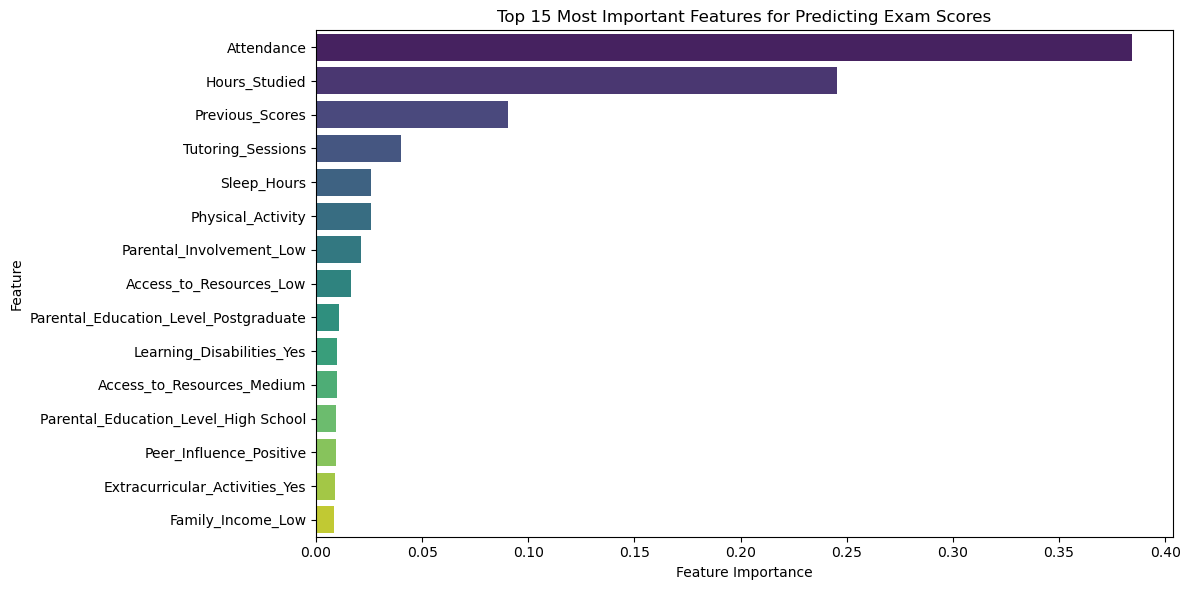

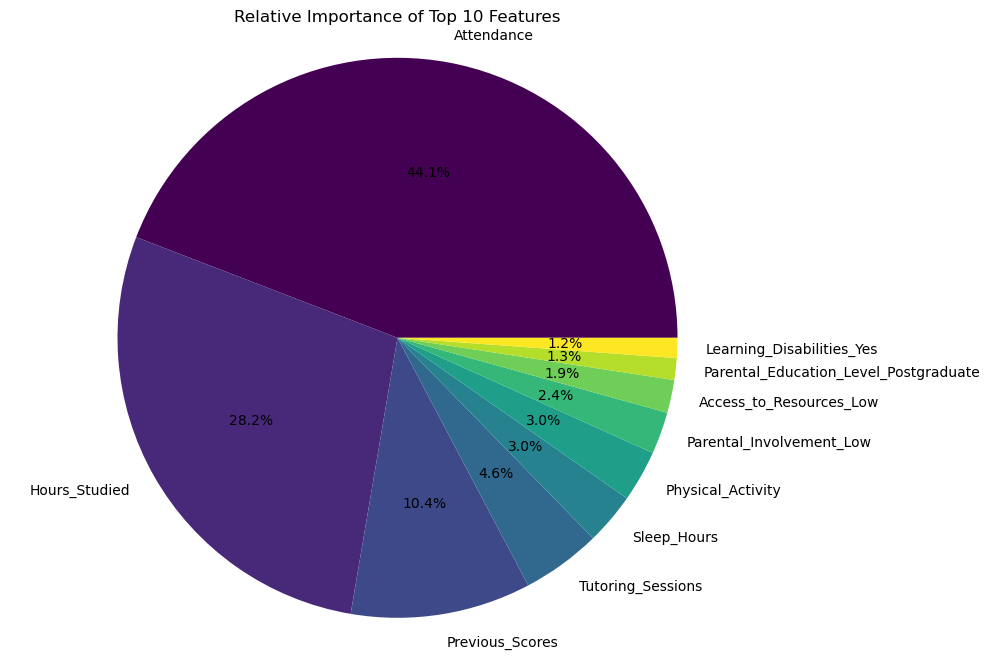

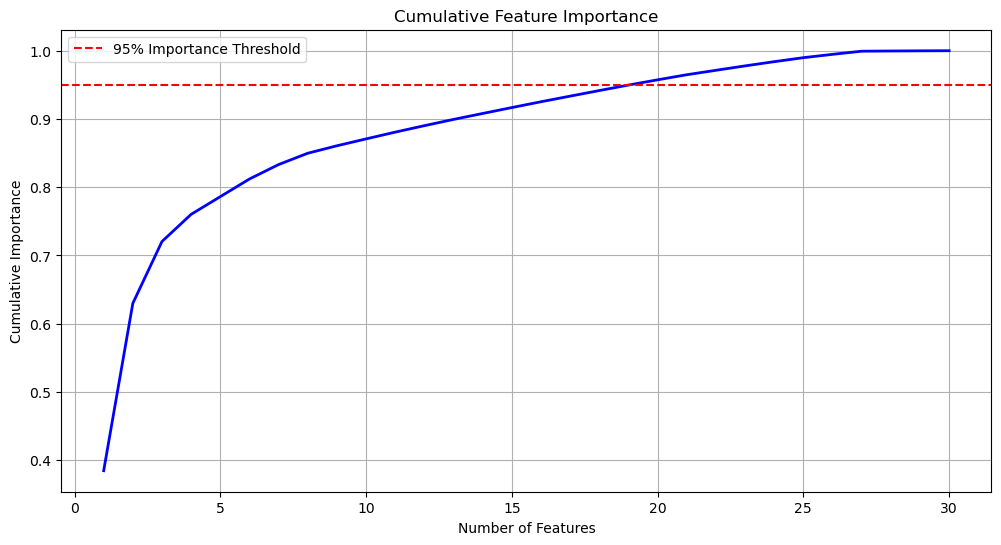


Feature Importance Summary:
Number of features explaining 95% of variance: 19

Importance by feature type:
Numerical features: 81.20%
Categorical features: 18.80%

Importance of categorical columns:
Parental_Involvement: 2.92%
Access_to_Resources: 2.65%
Parental_Education_Level: 2.07%
Peer_Influence: 1.56%
Distance_from_Home: 1.50%
Family_Income: 1.48%
Motivation_Level: 1.33%
Teacher_Quality: 1.33%
Learning_Disabilities: 1.01%
Extracurricular_Activities: 0.87%
School_Type: 0.82%
Gender: 0.77%
Internet_Access: 0.49%


In [123]:
# Get feature names after preprocessing
feature_names = (
    list(numerical_columns) +
    [f"{col}_{val}" for col, vals in 
     zip(categorical_columns,
         model.named_steps['preprocessor']
         .named_transformers_['cat']
         .categories_) 
     for val in vals[1:]]
)

# Get feature importance scores
importance = model.named_steps['regressor'].feature_importances_

# Create a dataframe of feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Display top 15 most important features
print("Top 15 Most Important Features:")
display(feature_importance.head(15))

# Create visualizations
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance.head(15), 
            x='Importance', 
            y='Feature', 
            palette='viridis')
plt.title('Top 15 Most Important Features for Predicting Exam Scores')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Create a pie chart for the top 10 features
plt.figure(figsize=(10, 8))
plt.pie(feature_importance.head(10)['Importance'], 
        labels=feature_importance.head(10)['Feature'],
        autopct='%1.1f%%',
        colors=plt.cm.viridis(np.linspace(0, 1, 10)))
plt.title('Relative Importance of Top 10 Features')
plt.axis('equal')
plt.show()

# Calculate cumulative importance
feature_importance['Cumulative_Importance'] = feature_importance['Importance'].cumsum()

# Plot cumulative importance
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(feature_importance) + 1), 
         feature_importance['Cumulative_Importance'], 
         'b-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Importance Threshold')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.legend()
plt.grid(True)
plt.show()

# Print summary statistics
print("\nFeature Importance Summary:")
print(f"Number of features explaining 95% of variance: "
      f"{(feature_importance['Cumulative_Importance'] <= 0.95).sum()}")
print("\nImportance by feature type:")
numerical_importance = sum(importance[:(len(numerical_columns))])
categorical_importance = sum(importance[(len(numerical_columns)):])
print(f"Numerical features: {numerical_importance:.2%}")
print(f"Categorical features: {categorical_importance:.2%}")

# Group categorical features by original column
categorical_importance_by_column = {}
current_idx = len(numerical_columns)
for col, vals in zip(categorical_columns,
                    model.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .categories_):
    n_categories = len(vals) - 1  # subtract 1 because we dropped one category
    importance_sum = sum(importance[current_idx:current_idx + n_categories])
    categorical_importance_by_column[col] = importance_sum
    current_idx += n_categories

print("\nImportance of categorical columns:")
for col, imp in sorted(categorical_importance_by_column.items(), 
                      key=lambda x: x[1], 
                      reverse=True):
    print(f"{col}: {imp:.2%}")

In [ ]:
# Save key visualizations for the LaTeX report

# Create and save correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, 
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f')
plt.title('Correlation Heatmap of Continuous Variables')
plt.tight_layout()
plt.savefig('report/images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()

# Save VIF scores plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Variable', y='VIF', data=vif_scores)
plt.title('Variance Inflation Factors for Continuous Variables')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=5, color='r', linestyle='--', label='Moderate Multicollinearity Threshold')
plt.axhline(y=10, color='darkred', linestyle='--', label='High Multicollinearity Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('report/images/vif_scores.png', dpi=300, bbox_inches='tight')
plt.close()

# Save categorical distribution plot (bar chart)
fig = plt.figure(figsize=(20, 5*n_rows))
fig.suptitle('Distribution of Categorical Variables', fontsize=16, y=1.02)
# ... (rest of the categorical plotting code)
plt.savefig('report/images/categorical_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# Save feature importance plot
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features for Predicting Exam Scores')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('report/images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.close()

# Save cumulative importance plot
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(feature_importance) + 1), 
         feature_importance['Cumulative_Importance'], 
         'b-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Importance Threshold')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('report/images/cumulative_importance.png', dpi=300, bbox_inches='tight')
plt.close()